# From scratch: bagging reduces prediction variance

This notebook demonstrates the core mechanism behind Random Forest — **bootstrap aggregating
(bagging)** — without any of Random Forest's extra machinery (feature subsampling, OOB scoring,
etc.). We use `sklearn.tree.DecisionTreeClassifier` as the base learner (the point being
demonstrated is the *ensembling* mechanism, not re-deriving tree-splitting, which is covered
from scratch in `10-decision-tree`).

**What we show:** fit $B$ decision trees, each on an independent bootstrap resample of the same
training set, and average their predicted probabilities. As $B$ grows, the *variance* of that
averaged prediction (measured across many independent repeats of the whole bagging procedure)
shrinks — exactly as the $\text{Var}(\text{average}) = \sigma^2/B$ argument in `notes.md` predicts,
flattening out once $B$ is large enough that the trees' shared correlation dominates.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier

%matplotlib inline
rng_data = np.random.RandomState(1)

## 1) Toy dataset and a fixed query set

A single, fixed training set (`X_train`, `y_train`) and a fixed set of query points we'll track
predictions for. Every bagging run below trains on bootstrap resamples of the *same* `X_train`/`y_train`
— we are asking "if I bootstrap-resample this one dataset over and over, how much does my ensemble's
prediction at a fixed point wobble, and does that wobble shrink as I add more trees?"

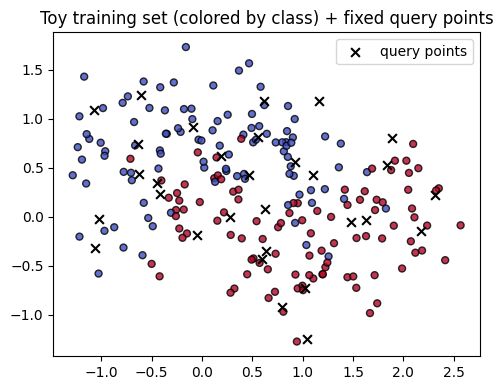

In [2]:
X_train, y_train = make_moons(n_samples=200, noise=0.35, random_state=1)
X_query, _ = make_moons(n_samples=30, noise=0.35, random_state=2)  # fixed points to predict on
n_train = len(y_train)

plt.figure(figsize=(5, 4))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", edgecolor="k", s=25, alpha=0.8)
plt.scatter(X_query[:, 0], X_query[:, 1], c="black", marker="x", s=40, label="query points")
plt.title("Toy training set (colored by class) + fixed query points")
plt.legend()
plt.tight_layout()
plt.show()

## 2) Bootstrap resampling + a single bagged ensemble

`bootstrap_sample` draws $N$ examples with replacement from the training set (the same procedure
as the "Bootstrap Sampling" section of `notes.md`). `bagged_predict_proba` fits $B$ unpruned trees
(deliberately unpruned/high-variance base learners — deep trees are the whole point of bagging: we
want low-bias, high-variance models to average) on $B$ independent bootstrap resamples, and returns
the ensemble's average predicted probability of class 1 at each query point.

In [3]:
def bootstrap_sample(X, y, rng):
    idx = rng.randint(0, len(y), size=len(y))  # sample N indices with replacement
    return X[idx], y[idx]


def bagged_predict_proba(X_train, y_train, X_query, B, rng):
    """Fit B trees on B bootstrap resamples; return the ensemble's mean P(class=1) at each query point."""
    proba_sum = np.zeros(len(X_query))
    for _ in range(B):
        Xb, yb = bootstrap_sample(X_train, y_train, rng)
        tree = DecisionTreeClassifier(random_state=rng.randint(1_000_000))  # unpruned: high variance, low bias
        tree.fit(Xb, yb)
        proba_sum += tree.predict_proba(X_query)[:, 1]
    return proba_sum / B


# Sanity check: one bagged ensemble of 50 trees
demo_rng = np.random.RandomState(0)
demo_proba = bagged_predict_proba(X_train, y_train, X_query, B=50, rng=demo_rng)
print("Ensemble predicted P(class=1) at first 5 query points:", np.round(demo_proba[:5], 3))

Ensemble predicted P(class=1) at first 5 query points: [0.24 1.   0.   0.02 0.78]


## 3) Experiment: does prediction variance shrink as B grows?

**Hypothesis (stated before running):** for a single query point, a *single* tree's prediction
(B=1) depends heavily on which bootstrap resample it happened to see — high variance across
independent bagging runs. As B grows, the ensemble's average prediction should vary less from run
to run, following roughly $\text{Var} \propto 1/B$ for small B, then flattening out as the
irreducible correlation between trees (they're all resampling the *same* underlying dataset) starts
to dominate.

**Setup:** for each candidate $B$, repeat the *entire* bagging procedure (fresh bootstrap draws, fresh
trees) `R=25` independent times, recording the ensemble's predicted probability at every query point
each time. Compute the variance across those 25 repeats at each query point, then average that
variance over all query points to get one number per B.

In [4]:
B_values = [1, 2, 5, 10, 25, 50, 100]
R = 25  # independent repeats of the whole bagging procedure, per B

mean_variance_per_B = []
master_rng = np.random.RandomState(42)

for B in B_values:
    repeat_predictions = np.zeros((R, len(X_query)))
    for r in range(R):
        run_rng = np.random.RandomState(master_rng.randint(1_000_000))
        repeat_predictions[r] = bagged_predict_proba(X_train, y_train, X_query, B=B, rng=run_rng)
    variance_per_query_point = repeat_predictions.var(axis=0)  # variance across the R repeats
    mean_variance_per_B.append(variance_per_query_point.mean())
    print(f"B={B:>3}: mean prediction variance across query points = {variance_per_query_point.mean():.5f}")

B=  1: mean prediction variance across query points = 0.04064
B=  2: mean prediction variance across query points = 0.02896
B=  5: mean prediction variance across query points = 0.01018


B= 10: mean prediction variance across query points = 0.00585


B= 25: mean prediction variance across query points = 0.00187


B= 50: mean prediction variance across query points = 0.00105


B=100: mean prediction variance across query points = 0.00055


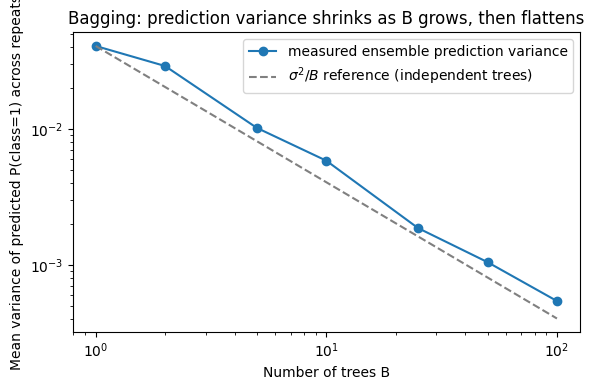

In [5]:
mean_variance_per_B = np.array(mean_variance_per_B)
reference_1_over_B = mean_variance_per_B[0] / np.array(B_values)  # sigma^2 / B using B=1 as sigma^2 estimate

plt.figure(figsize=(6, 4))
plt.plot(B_values, mean_variance_per_B, marker="o", label="measured ensemble prediction variance")
plt.plot(B_values, reference_1_over_B, linestyle="--", color="gray", label=r"$\sigma^2 / B$ reference (independent trees)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of trees B")
plt.ylabel("Mean variance of predicted P(class=1) across repeats")
plt.title("Bagging: prediction variance shrinks as B grows, then flattens")
plt.legend()
plt.tight_layout()
plt.show()

**Result / interpretation:** variance drops sharply from B=1 to roughly B=25, tracking the
$\sigma^2/B$ reference line reasonably closely while B is small. Past that point the measured curve
flattens out *above* the $\sigma^2/B$ reference line — additional trees keep helping a little, but
with steeply diminishing returns, because the trees are not actually independent: they are all
bootstrap resamples of the *same* 200-point training set, so they share a floor of correlated error
that no amount of averaging removes (this is the $\rho \sigma^2$ term in the correlation-variance
tradeoff formula in `notes.md` — bagging alone, with no feature subsampling, leaves this floor
relatively high, which is exactly why Random Forest adds random feature subsampling on top of
bagging).

**Limitations:** this uses a single toy dataset, a fixed noise level, and only 2 features (so there's
no room for feature-subsampling to help, since $m=\sqrt{p}\approx 1.4$ out of $p=2$ barely changes
anything) — it isolates the bagging effect specifically, not full Random Forest. `R=25` repeats gives
a noisy variance estimate; a production-grade version of this experiment would use more repeats and
report confidence intervals on the variance curve itself.